<a href="https://colab.research.google.com/github/hemanthch517-lab/ML/blob/main/Copy_of_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 Rows:
   Survived  Pclass                                               Name  \
0         0       3                             Mr. Owen Harris Braund   
1         1       1  Mrs. John Bradley (Florence Briggs Thayer) Cum...   
2         1       3                              Miss. Laina Heikkinen   
3         1       1        Mrs. Jacques Heath (Lily May Peel) Futrelle   
4         0       3                            Mr. William Henry Allen   

      Sex   Age  Siblings/Spouses Aboard  Parents/Children Aboard     Fare  
0    male  22.0                        1                        0   7.2500  
1  female  38.0                        1                        0  71.2833  
2  female  26.0                        0                        0   7.9250  
3  female  35.0                        1                        0  53.1000  
4    male  35.0                        0                        0   8.0500  

Dataset Shape:
(887, 8)

Column Names:
Index(['Survived', 'Pclass', 'Name', 'S

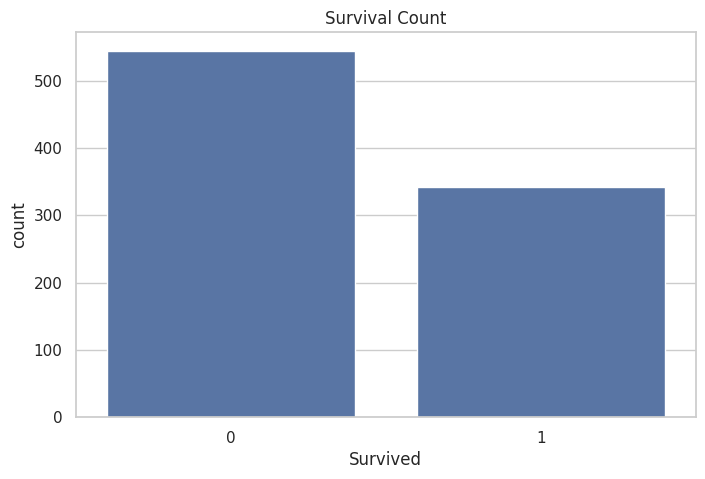

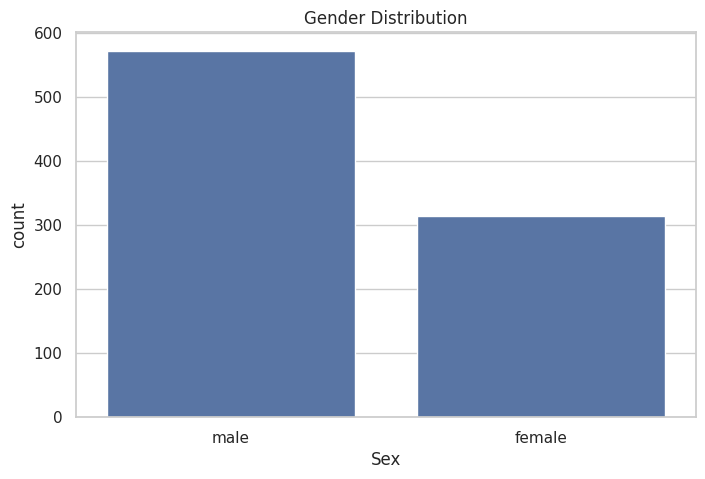

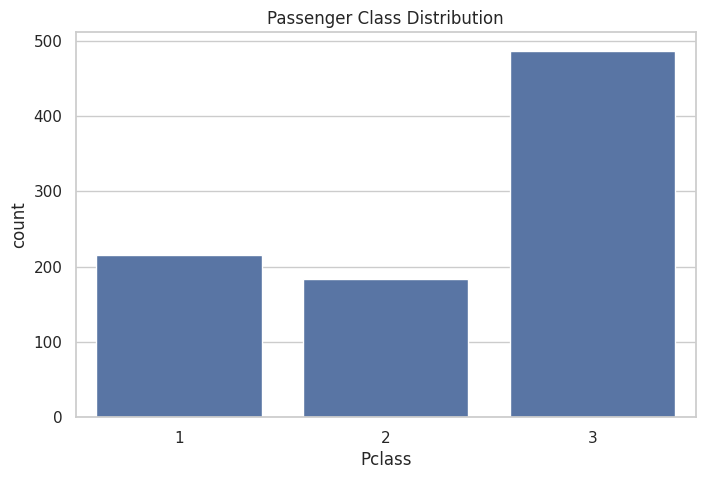

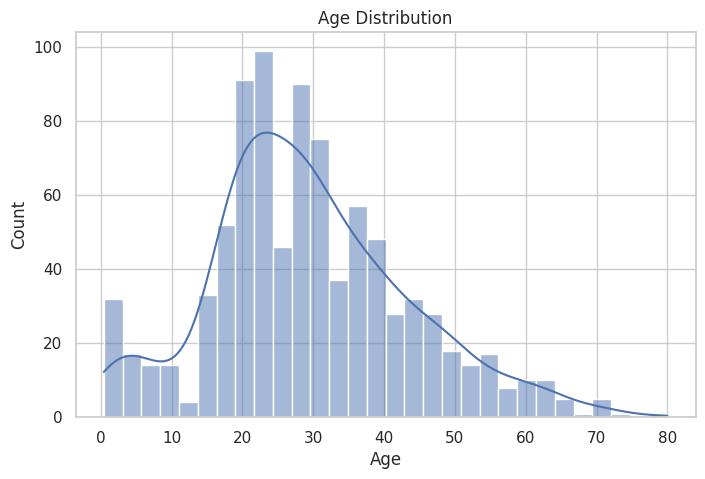

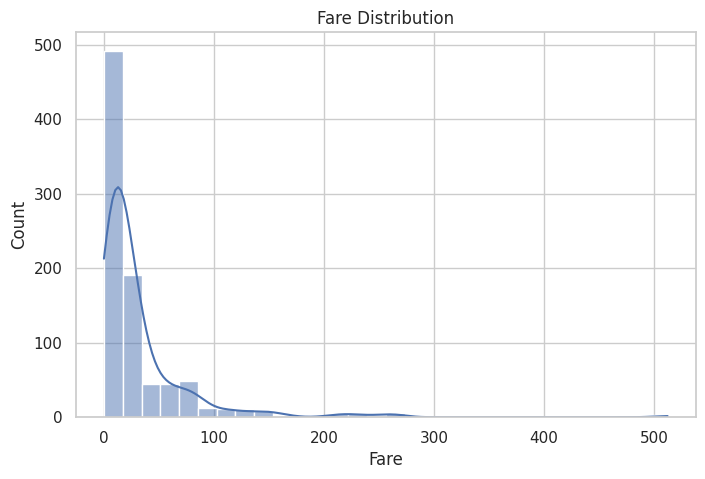

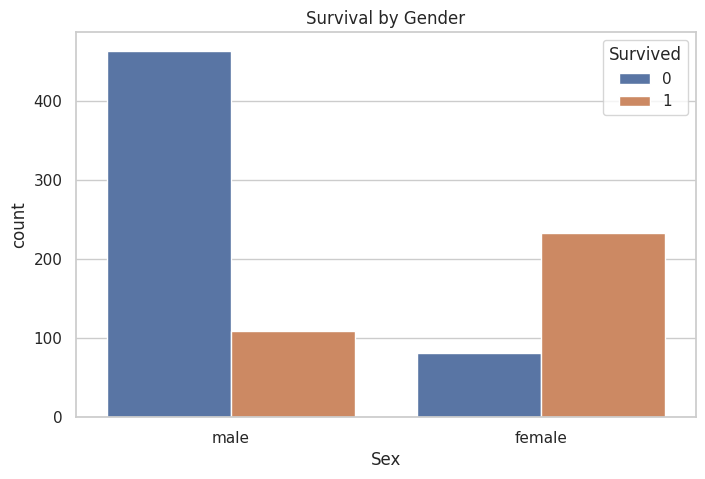

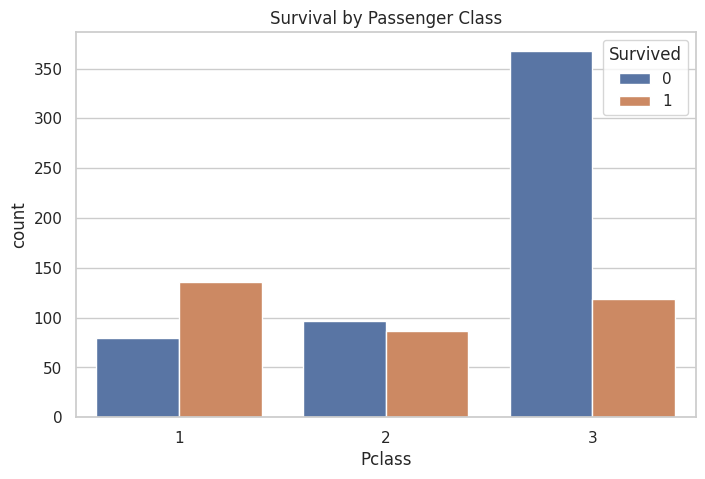

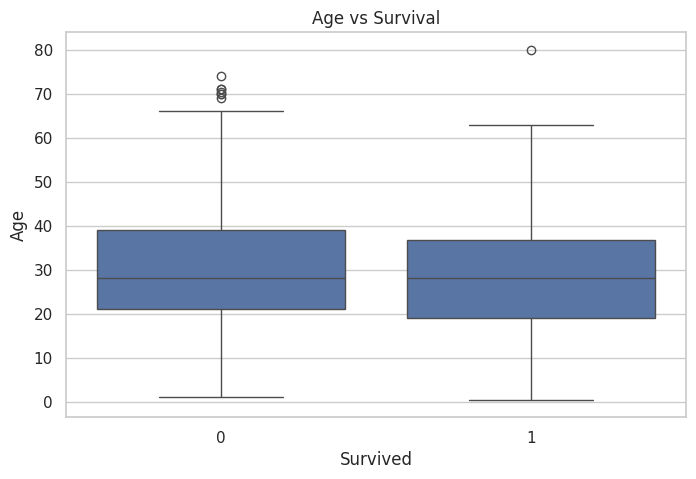

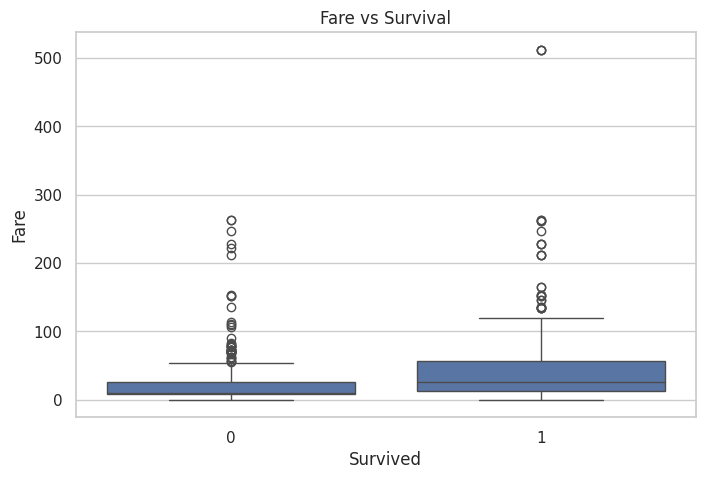

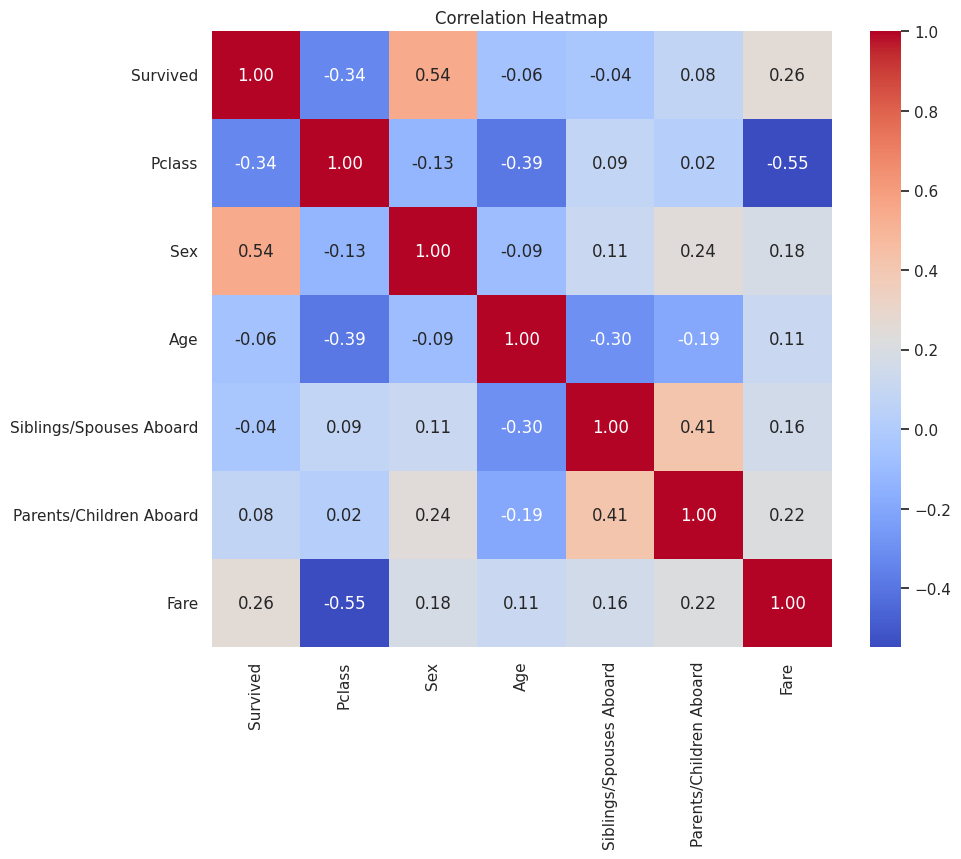

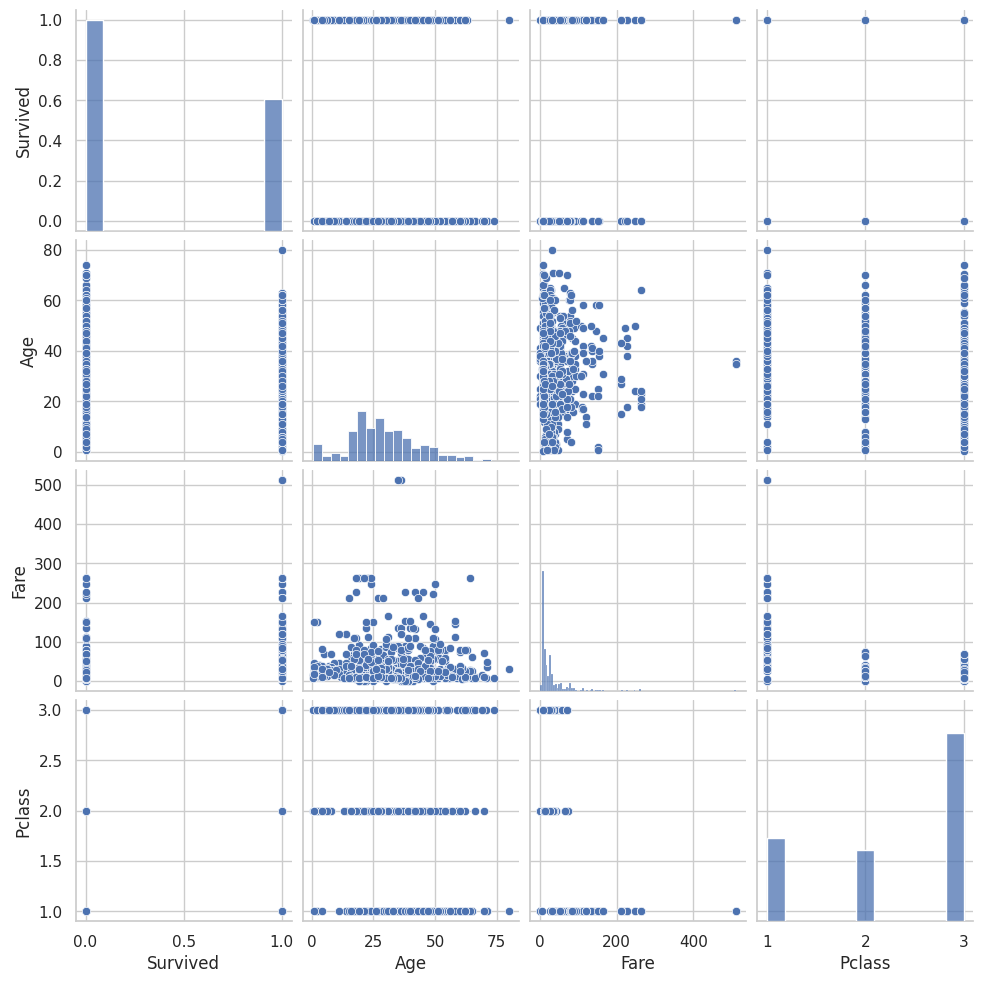

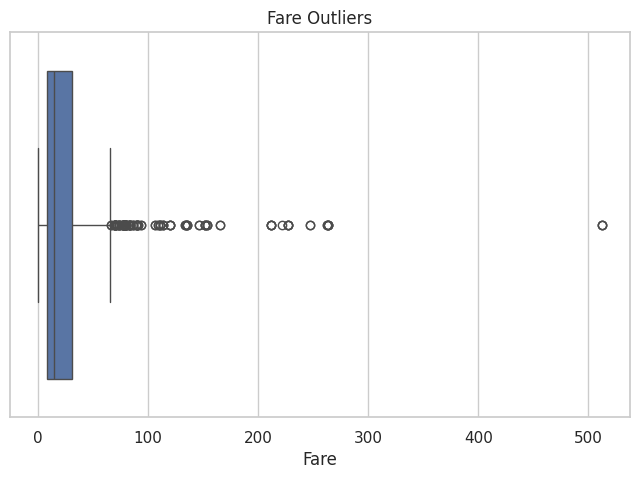

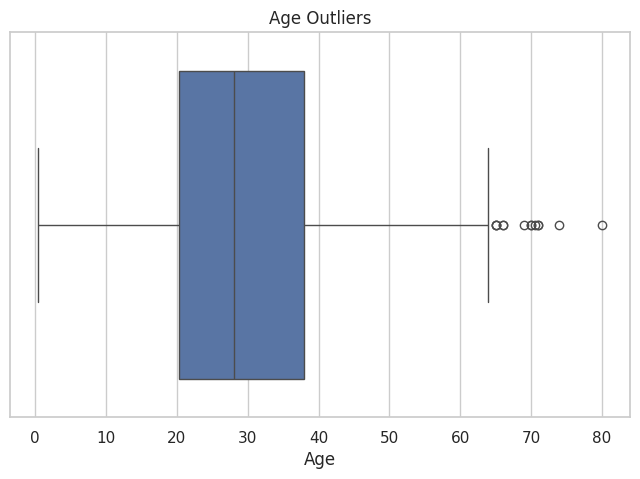


========== EDA Summary ==========
1. Dataset Shape : (887, 8)
2. Missing values handled.
3. Cabin column removed.
4. Duplicate rows removed.
5. Females generally have a higher survival rate.
6. First-class passengers survived more often.
7. Higher fare is associated with better survival.
8. Most passengers were between 20 and 40 years old.


In [ ]:
# ================================
# Exploratory Data Analysis (EDA)
# Titanic Dataset
# ================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Display Settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# Load Dataset
# Check if the dataset exists, if not, download it
if not os.path.exists("Titanic-Dataset.csv"):
    !wget -q https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv -O Titanic-Dataset.csv
df = pd.read_csv("Titanic-Dataset.csv")

# ================================
# Basic Information
# ================================
print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe(include='all'))

# ================================
# Missing Values
# ================================
print("\nMissing Values:")
print(df.isnull().sum())

# Fill Missing Values
df['Age'] = df['Age'].fillna(df['Age'].median())
# The 'Embarked' column does not exist in this dataset, so this line will cause an error.
# df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column
# The 'Cabin' column also does not exist in this dataset, so this check will prevent an error.
if 'Cabin' in df.columns:
    df.drop(columns='Cabin', inplace=True)

# ================================
# Duplicate Values
# ================================
print("\nDuplicate Rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

# ================================
# Univariate Analysis
# ================================

# Survival Count
plt.figure()
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

# Gender Count
plt.figure()
sns.countplot(x='Sex', data=df)
plt.title("Gender Distribution")
plt.show()

# Passenger Class
plt.figure()
sns.countplot(x='Pclass', data=df)
plt.title("Passenger Class Distribution")
plt.show()

# Age Distribution
plt.figure()
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

# Fare Distribution
plt.figure()
sns.histplot(df['Fare'], bins=30, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.show()

# ================================
# Bivariate Analysis
# ================================

# Survival vs Gender
plt.figure()
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

# Survival vs Passenger Class
plt.figure()
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()

# Age vs Survival
plt.figure()
sns.boxplot(x='Survived', y='Age', data=df)
plt.title("Age vs Survival")
plt.show()

# Fare vs Survival
plt.figure()
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title("Fare vs Survival")
plt.show()

# ================================
# Correlation Heatmap
# ================================

# Convert Categorical Columns
df_corr = df.copy()
df_corr['Sex'] = df_corr['Sex'].map({'male':0, 'female':1})
# The 'Embarked' column does not exist in this dataset, so this line is removed.
# df_corr['Embarked'] = df_corr['Embarked'].map({'S':0, 'C':1, 'Q':2})

plt.figure(figsize=(10,8))
sns.heatmap(df_corr.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

# ================================
# Pairplot
# ================================
sns.pairplot(df[['Survived','Age','Fare','Pclass']])
plt.show()

# ================================
# Outlier Detection
# ================================

plt.figure()
sns.boxplot(x=df['Fare'])
plt.title("Fare Outliers")
plt.show()

plt.figure()
sns.boxplot(x=df['Age'])
plt.title("Age Outliers")
plt.show()

# ================================
# Final Summary
# ================================

print("\n========== EDA Summary ==========")
print("1. Dataset Shape :", df.shape)
print("2. Missing values handled.")
print("3. Cabin column removed.")
print("4. Duplicate rows removed.")
print("5. Females generally have a higher survival rate.")
print("6. First-class passengers survived more often.")
print("7. Higher fare is associated with better survival.")
print("8. Most passengers were between 20 and 40 years old.")
print("=================================")